In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv("Employee Turnover Dataset.csv")

In [99]:
df.shape

(10199, 16)

In [100]:
df.duplicated().sum()

99

In [101]:
df.isna().sum()

EmployeeNumber                     0
Age                                0
Tenure                             0
Turnover                           0
HourlyRate                         0
HoursWeekly                        0
CompensationType                   0
AnnualSalary                       0
DrivingCommuterDistance            0
JobRoleArea                        0
Gender                             0
MaritalStatus                      0
NumCompaniesPreviouslyWorked     665
AnnualProfessionalDevHrs        1969
PaycheckMethod                     0
TextMessageOptIn                2266
dtype: int64

In [102]:
print(df.dtypes)

EmployeeNumber                    int64
Age                               int64
Tenure                            int64
Turnover                         object
HourlyRate                       object
HoursWeekly                       int64
CompensationType                 object
AnnualSalary                    float64
DrivingCommuterDistance           int64
JobRoleArea                      object
Gender                           object
MaritalStatus                    object
NumCompaniesPreviouslyWorked    float64
AnnualProfessionalDevHrs        float64
PaycheckMethod                   object
TextMessageOptIn                 object
dtype: object


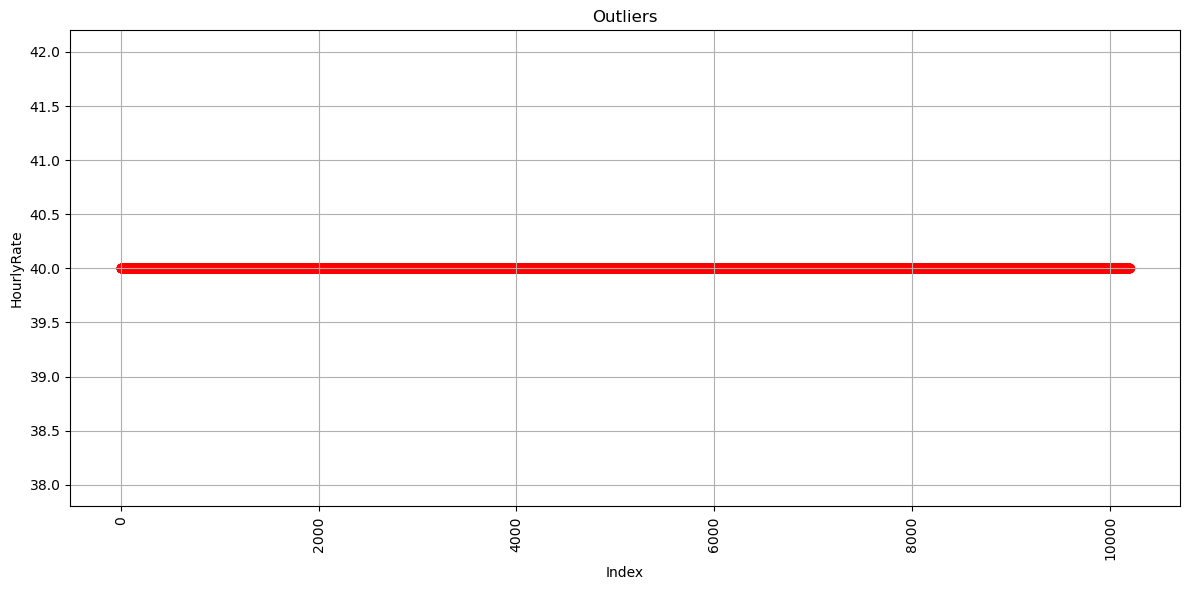

In [103]:
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['HoursWeekly'], color='red')
plt.title('Outliers')
plt.xlabel('Index')
plt.ylabel('HourlyRate')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
df[df['PaycheckMethod'].str.contains('mail', case=False, na=False)]

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
0,1,28,6,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,3.0,7.0,Mail Check,Yes
1,2,33,2,Yes,$24.37,40,Salary,50689.6,89,Research,Female,Married,6.0,7.0,Mail Check,Yes
2,3,22,1,No,$22.52,40,Salary,46841.6,35,Information_Technology,Female,Single,1.0,8.0,Mailed Check,Yes
3,4,23,1,No,$22.52,40,Salary,46841.6,35,Information_Technology,Female,Single,3.0,NaN,Mailed Check,Yes
4,5,40,6,No,$88.77,40,Salary,284641.6,12,Sales,Prefer Not to Answer,Single,7.0,NaN,Mail Check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10194,95,48,13,Yes,$85.40,40,Salary,177632.0,31,Research,Male,Single,7.0,5.0,Mail Check,NaN
10195,96,54,17,No,$85.40,40,Salary,177632.0,31,Research,Male,Single,2.0,25.0,Mail Check,Yes
10196,97,44,6,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,6.0,NaN,Mail Check,Yes
10197,98,58,19,No,$71.90,40,Salary,149552.0,32,Marketing,Male,Married,5.0,23.0,Mail Check,Yes


In [134]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: EmployeeNumber
[    1     2     3 ... 10098 10099 10100]

Column: Age
[28 33 22 23 40 45 34 37 24 30 38 47 55 59 29 35 44 54 36 32 41 56 21 27
 50 31 46 48 39 57 52 53 58 49 42 60 43 61 26 51 25]

Column: Tenure
[ 6  2  1 16  9  3  8  4 20 10  7 15  5 18 17 14 13 19 12 11]

Column: Turnover
['Yes' 'No']

Column: HourlyRate 
['$24.37 ' '$22.52 ' '$88.77 ' ... '$30.86 ' '$95.07 ' '$93.05 ']

Column: HoursWeekly
[40]

Column: CompensationType
['Salary']

Column: AnnualSalary
[ 50689.6  46841.6 284641.6 ... 337745.6 164902.4 333544. ]

Column: DrivingCommuterDistance
[  89   35   12    0   76   15    2   36   60   14   75    5  910   28
   -4   33   79   50   13   57   82    4   42   -5   64   -8   77    1
   24   67   41   62   47   -7   31   32   56   22   51   58   34   37
   16   26   74  -10   -2   84   44   61   87   46   52   73   53   85
   66   80   55  950   70   17  250  -12   43   49   81   86   -3   48
   45   68   10    7   20   38   21  -11   65   78   69   -6   25 

In [106]:
df2 = df.drop_duplicates()

In [107]:
df2.shape

(10100, 16)

In [63]:
df2.isnull().any(axis=1)

0        False
1        False
2        False
3         True
4         True
         ...  
10095    False
10096    False
10097     True
10098    False
10099     True
Length: 10100, dtype: bool

In [108]:
invalid_values = df2[(df2['DrivingCommuterDistance'] < 0)]
display (invalid_values)

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
30,31,30,1,No,$24.50,40,Salary,50960.0,-4,Human_Resources,Female,Divorced,3.0,17.0,Mailed Check,Yes
31,32,34,2,No,$24.50,40,Salary,50960.0,-4,Human_Resources,Female,Divorced,3.0,NaN,Mailed Check,Yes
54,55,44,16,No,$31.30,40,Salary,-15896.0,-5,Marketing,Male,Divorced,8.0,22.0,Mail Check,Yes
55,56,50,8,No,$31.30,40,Salary,-15896.0,-5,Marketing,Male,Divorced,5.0,10.0,Mail Check,Yes
64,65,30,3,Yes,$29.49,40,Salary,-28660.8,-8,Marketing,Female,Married,1.0,19.0,Mail Check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10029,10030,44,5,No,$92.48,40,Salary,332358.4,-7,Marketing,Female,Single,5.0,NaN,Mail Check,NaN
10039,10040,61,18,No,$71.91,40,Salary,149572.8,-6,Sales,Female,Divorced,4.0,16.0,Mailed Check,Yes
10041,10042,61,14,Yes,$33.25,40,Salary,69160.0,-5,Manufacturing,Male,Divorced,9.0,9.0,Mailed Check,NaN
10096,10097,33,9,Yes,$23.28,40,Salary,48422.4,-10,Marketing,Male,Single,1.0,20.0,Direct_Deposit,Yes


In [118]:
invalid_values2 = df2[(df2['AnnualSalary'] < 0)]
display (invalid_values2)

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn
54,55,44,16,No,$31.30,40,Salary,-15896.0,-5,Marketing,Male,Divorced,8.0,22.0,Mail Check,Yes
55,56,50,8,No,$31.30,40,Salary,-15896.0,-5,Marketing,Male,Divorced,5.0,10.0,Mail Check,Yes
64,65,30,3,Yes,$29.49,40,Salary,-28660.8,-8,Marketing,Female,Married,1.0,19.0,Mail Check,Yes
65,66,32,5,Yes,$29.49,40,Salary,-28660.8,-8,Marketing,Female,Married,3.0,8.0,Mail Check,Yes
541,542,37,7,No,$31.72,40,Salary,-15022.4,48,Marketing,Female,Divorced,2.0,16.0,Direct_Deposit,Yes
605,606,47,9,No,$32.58,40,Salary,-10433.6,125,Marketing,Male,Divorced,NaN,NaN,Direct_Deposit,Yes
658,659,30,3,Yes,$30.06,40,Salary,-14475.2,46,Marketing,Female,Married,2.0,NaN,Direct_Deposit,Yes
863,864,37,7,No,$30.99,40,Salary,-16540.8,60,Marketing,Male,Divorced,4.0,NaN,Mail Check,Yes
1015,1016,40,9,Yes,$31.73,40,Salary,-15001.6,-3,Marketing,Female,Single,NaN,NaN,Direct_Deposit,No
1320,1321,36,10,Yes,$32.60,40,Salary,-10392.0,87,Marketing,Male,Single,4.0,NaN,Mail Check,Yes


In [109]:
invalid_values.count()

EmployeeNumber                  1343
Age                             1343
Tenure                          1343
Turnover                        1343
HourlyRate                      1343
HoursWeekly                     1343
CompensationType                1343
AnnualSalary                    1343
DrivingCommuterDistance         1343
JobRoleArea                     1343
Gender                          1343
MaritalStatus                   1343
NumCompaniesPreviouslyWorked    1256
AnnualProfessionalDevHrs        1071
PaycheckMethod                  1343
TextMessageOptIn                1074
dtype: int64

In [110]:
df3 = df2.dropna()

In [112]:
df3.shape

(5917, 16)

In [116]:
df3.loc[:, 'DrivingCommuterDistance'] = df3['DrivingCommuterDistance'].abs()

In [117]:
invalid_values = df3[(df3['DrivingCommuterDistance'] < 0)]
display (invalid_values)

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn


In [120]:
df3.loc[:, 'AnnualSalary'] = df3['AnnualSalary'].abs()

In [121]:
invalid_values2 = df3[(df3['AnnualSalary'] < 0)]
display (invalid_values2)

,EmployeeNumber,Age,Tenure,Turnover,HourlyRate,HoursWeekly,CompensationType,AnnualSalary,DrivingCommuterDistance,JobRoleArea,Gender,MaritalStatus,NumCompaniesPreviouslyWorked,AnnualProfessionalDevHrs,PaycheckMethod,TextMessageOptIn


In [124]:
df4 = df3[df3['HoursWeekly'] == 40]
df4.shape

(5917, 16)

In [131]:
print(df4.dtypes)

EmployeeNumber                    int64
Age                               int64
Tenure                            int64
Turnover                         object
HourlyRate                       object
HoursWeekly                       int64
CompensationType                 object
AnnualSalary                    float64
DrivingCommuterDistance           int64
JobRoleArea                      object
Gender                           object
MaritalStatus                    object
NumCompaniesPreviouslyWorked    float64
AnnualProfessionalDevHrs        float64
PaycheckMethod                   object
TextMessageOptIn                 object
dtype: object


In [136]:
df4.loc[df4['PaycheckMethod'].str.contains('mail', case=False, na=False), 'PaycheckMethod'] = 'Mail Check'
df4.loc[df4['PaycheckMethod'].str.contains('direct', case=False, na=False), 'PaycheckMethod'] = 'Direct Deposit'

In [137]:
df4['PaycheckMethod'].unique()

array(['Mail Check', 'Direct Deposit'], dtype=object)